In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import optax
from flax import nnx
import orbax.checkpoint as ocp

from jaxpm import camels, data, plotting, graph
from jaxpm.painting import cic_paint, cic_read
from jaxpm.nn import MLP, CNN, HybridNet, AttentionGNN

jax.devices("gpu")

[cuda(id=0)]

# functions

## training

In [15]:
@nnx.jit(static_argnames="loss_type")
def train_step(model, optimizer, x, y, loss_type="mse"):

    def loss_fn(model):
        y_pred = model(*x, training=True)
        
        if loss_type == "mse":
            return jnp.mean((y - y_pred) **2)
        elif loss_type == "mae":
            return jnp.mean(jnp.abs(y - y_pred))

    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(grads)

    return loss

@nnx.jit(static_argnames="loss_type")
def vali_loop(model, X, Y, loss_type="mse"):
    losses = []
    for i in range(scales.shape[0]):
        x, y = tuple(x[i] for x in X), Y[i]
        y_pred = model(*x, training=True)

        if loss_type == "mse":
            losses.append(jnp.mean((y - model(*x))**2))
        elif loss_type == "mae":
            losses.append(jnp.mean(jnp.abs(y - model(*x))))
            
    losses = jnp.mean(jnp.stack(losses))

    return losses
    
# NOTE this is GD, not SGD. There's no batches, all particles in the snapshot are evaluated every step
def train_model(
    model, 
    X,
    Y,
    X_vali,
    Y_vali,
    loss_type="mse",
    total_steps=10_000,
    vali_every=100,
    learning_rate=1e-3,
    cosine_decay=True,
):
    optimizer = optax.chain(
        optax.clip_by_global_norm(1),
        optax.adam(learning_rate)
    )
    optimizer = nnx.Optimizer(model, optimizer)

    if cosine_decay:
        learning_rate = optax.cosine_decay_schedule(
            init_value=learning_rate, 
            decay_steps=total_steps, 
            alpha=0.1
        )

    losses = []
    vali_steps = []
    vali_losses = []
    vali_loss = np.inf
    for i in (pbar := tqdm.tqdm(range(total_steps))):
        # select single snapshot
        j = np.random.choice(np.arange(scales.shape[0]))
        x, y = tuple(x[j] for x in X), Y[j]
        
        loss = train_step(model, optimizer, x, y, loss_type=loss_type)
        losses.append(loss)

        if (i % vali_every == 0) and (i != 0) or i == total_steps - 1:
            vali_steps.append(i)
            vali_loss = vali_loop(model, X_vali, Y_vali, loss_type=loss_type)
            vali_losses.append(vali_loss)

        pbar.set_description(f"train={loss:.4f}, vali={vali_loss:.4f}")

    fig, ax = plt.subplots()
    ax.plot(losses, label="training")
    ax.plot(vali_steps, vali_losses, label="validation")
    ax.legend(loc="upper right")
    ax.set(yscale="log")

    return losses, vali_losses
    

## plotting

In [4]:
def plot_preds(pred, label, pred_vali, label_vali, title="", out_file=None):
    nrows = pred_vali.shape[0]
    ncols = 2
    
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(2*ncols,2*nrows))

    for i in range(nrows):
        ax[i,0].scatter(label[i], pred[i], s=0.1, color="tab:blue")
    
        ax[i,0].plot([label[i].min(), label[i].max()], [label[i].min(), label[i].max()], color="k", linestyle="--")
        ax[i,0].set_aspect("equal")
        ax[i,0].set_box_aspect(1)
        ax[i,0].set_yticks(ax[i,0].get_xticks())

    ax[0,0].set(title="training")
    
    for i in range(nrows):
        ax[i,1].scatter(label_vali[i], pred_vali[i], s=0.1, color="tab:orange")
    
        ax[i,1].plot([label_vali[i].min(), label_vali[i].max()], [label_vali[i].min(), label_vali[i].max()], color="k", linestyle="--")
        ax[i,1].set_aspect("equal")
        ax[i,1].set_box_aspect(1)
        ax[i,1].set_yticks(ax[i,1].get_xticks())
        
    ax[0,1].set(title="validation")

    fig.suptitle(title)
    fig.tight_layout()

    if out_file is not None:
        plt.savefig(out_file, bbox_inches="tight")

In [5]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3

## CAMELS snapshots

In [6]:
# i_snapshots = [-2, -1]
i_snapshots = range(1, 33+4, 4)
# i_snapshots = None

In [7]:
SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0"

train_dict = camels.load_CV_snapshots(
    SIM,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
)

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_034.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_050.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_066.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_082.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


loading snapshots: 100%|██████████| 9/9 [01:42<00:00, 11.35s/it]


In [8]:
SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1"

test_dict = camels.load_CV_snapshots(
    SIM,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
)

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_034.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_050.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_066.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_082.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


loading snapshots: 100%|██████████| 9/9 [01:45<00:00, 11.73s/it]


In [9]:
scales, particle_features, field_features = camels.preprocess_snapshots(train_dict)

# Network selection

In [18]:
def train_mlp(x_labels, y_labels, loss_type):
    X, _, Y, _ = data.get_offline_regression_data(train_dict, x_labels=x_labels, y_labels=y_labels)
    X_vali, _, Y_vali, _ = data.get_offline_regression_data(test_dict, x_labels=x_labels, y_labels=y_labels)

    model = MLP(
        X.shape[-1], 
        Y.shape[-1], 
        64, 
        4,
        nnx.Rngs(0),
        0.01,
    )
    
    loss, loss_vali = train_model(
        model,
        (X,),
        Y,
        (X_vali,),
        Y_vali,
        loss_type=loss_type,
    )

    pred = model(X)
    pred_vali = model(X_vali)
    
    # in log space
    plot_preds(pred, Y, pred_vali, Y_vali, title=loss_type, out_file=f"plots/{loss_type}.png")
    
    return model

# def train_hybrid(x_labels, y_labels):
#     X_particle, X_field, Y = get_data(train_dict, y_labels=y_labels)
#     X_particle_vali, X_field_vali, Y_vali = get_data(test_dict, y_labels=y_labels)
    
#     mlp = MLP(
#         d_in=X_particle.shape[-1], 
#         d_out=8, 
#         d_hidden=64, 
#         n_hidden=4, 
#         rngs=nnx.Rngs(0)
#     )
    
#     cnn = CNN(
#         d_in=X_field.shape[-1], 
#         d_out=8,
#         d_hidden=16,
#         n_hidden=1,
#         kernel_size=(3, 3, 3),
#         strides=1,
#         rngs=nnx.Rngs(0)
#     )
    
#     hybrid = HybridNet(
#         mlp,
#         cnn,
#         d_out=Y.shape[-1],
#         rngs=nnx.Rngs(0),
#         batch_axis=False,
#     )    
    # return hybrid


def train_gnn(x_labels, y_labels):
    X, Y = graph.get_graphs_from_snapshots(
        train_dict,
        x_labels=x_labels,
        y_labels=y_labels,
        k=16, 
        # boxsize=mesh_per_dim
    )
    
    X_vali, Y_vali = graph.get_graphs_from_snapshots(
        test_dict,
        x_labels=x_labels,
        y_labels=y_labels,
        k=16, 
        # boxsize=mesh_per_dim
    )

    model = AttentionGNN(
        d_node=X[0].nodes.shape[-1],
        d_edge=X[0].edges.shape[-1],
        d_query=16,
        n_hidden=4,
        d_out=Y.shape[-1],
        rngs=nnx.Rngs(0),
    )
    
    train_model(
        model,
        (X,),
        Y,
        (X_vali,),
        Y_vali,
    )
    
    return model


# predict P

### MSE

train=0.1311, vali=0.2176: 100%|██████████| 10000/10000 [01:41<00:00, 98.15it/s]


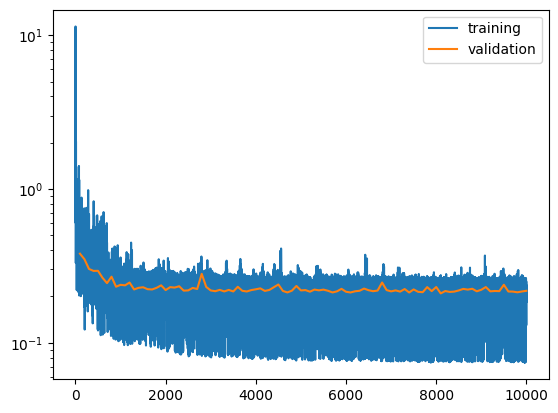

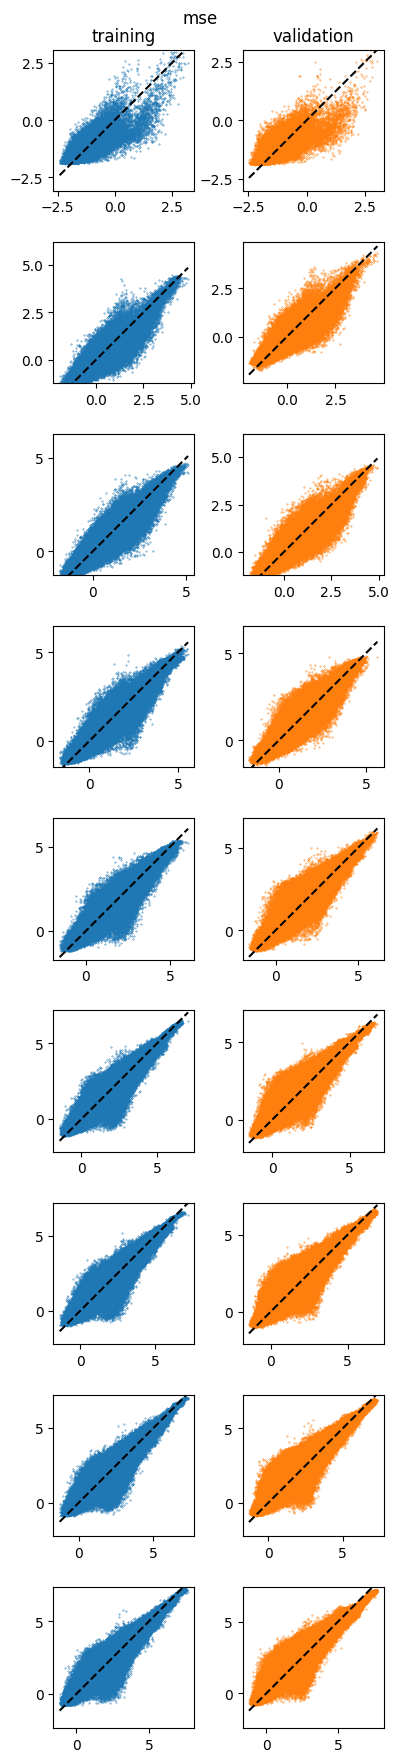

In [19]:
x_labels = ["rho", "fscalar", "vel_disp", "vel_div"]
y_labels = ["P"]

model = train_mlp(x_labels, y_labels, loss_type="mse")
# model = train_gnn(x_labels, y_labels)

### MAE

train=0.2644, vali=0.3384: 100%|██████████| 10000/10000 [01:50<00:00, 90.89it/s]


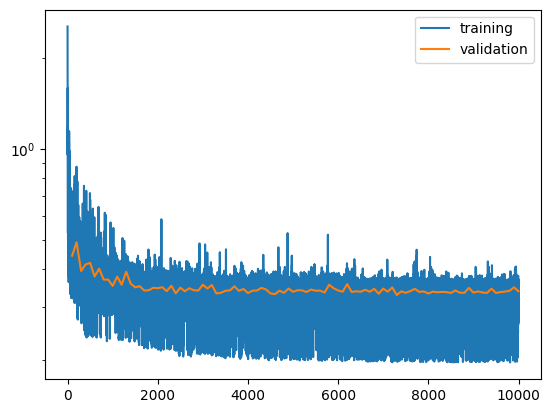

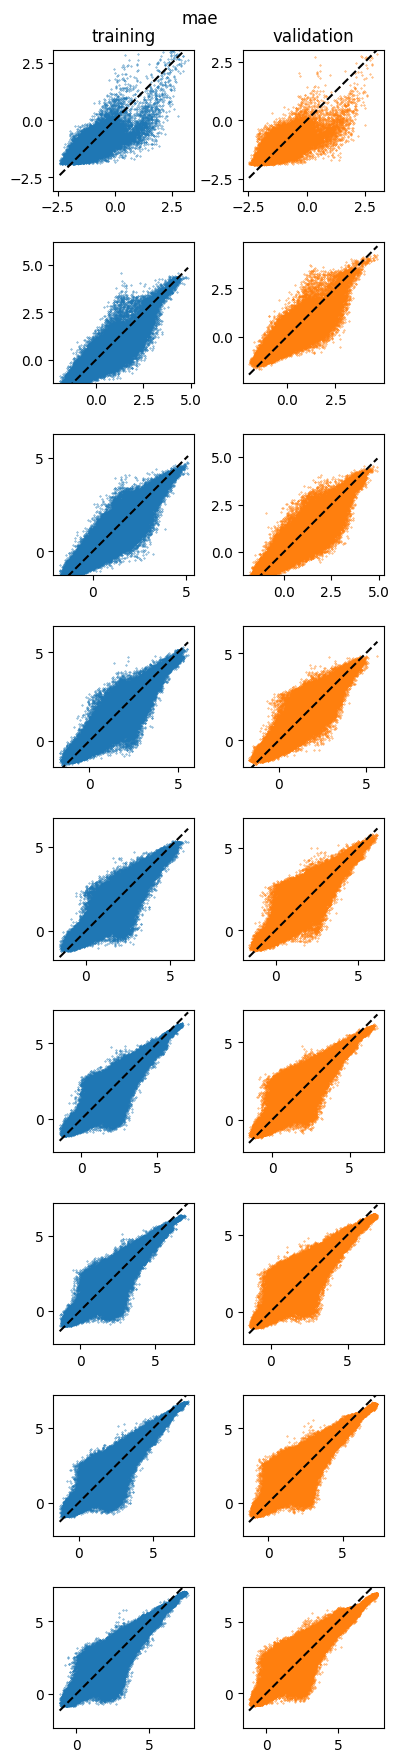

In [20]:
x_labels = ["rho", "fscalar", "vel_disp", "vel_div"]
y_labels = ["P"]

model = train_mlp(x_labels, y_labels, loss_type="mae")
# model = train_gnn(x_labels, y_labels)